In [1]:
import torch
from tqdm import tqdm
from scipy.ndimage.filters import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch.utils.data.sampler import Sampler
from torchvision import transforms
from PIL import Image
import time
from IPython.display import clear_output

import lovely_tensors as lt
lt.monkey_patch()

# Dummy class to store arguments
class Dummy():
    pass


# Function that opens image from disk, normalizes it and converts to tensor
read_tensor = transforms.Compose([
    lambda x: Image.open(x),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
    lambda x: torch.unsqueeze(x, 0)
])


# Plots image from tensor
def tensor_imshow(inp, title=None, **kwargs):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Mean and std for ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp, **kwargs)
    if title is not None:
        plt.title(title)


# Image preprocessing function
preprocess = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                # Normalization for ImageNet
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])


# Sampler for pytorch loader. Given range r loader will only
# return dataset[r] instead of whole dataset.
class RangeSampler(Sampler):
    def __init__(self, r):
        self.r = r

    def __iter__(self):
        return iter(self.r)

    def __len__(self):
        return len(self.r)


/tmp/ipykernel_2222067/2960153348.py:3: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [ ]:
import copy
from affex.data import get_dataloaders


PROMPT_IMAGES = [
    # 'frame0009_2.png',
    'frame0021_2.png',
    "frame0033_3.png",
    'frame0034_1.png',
    'frame0048_0.png',
]

PASCAL_NAME = "val_pascal5i"
PASCAL_PARAMS = {
    "name": "pascal",
    "data_dir": "data/pascal",
    "split": "val",
    "val_fold_idx": 3,
    "n_folds": 4,
    "n_shots": 2,
    "n_ways": 1,
    "do_subsample": False,
    "val_num_samples": 100,
    "ignore_borders": True,
}

parameters = {
    "dataloader": {
        "num_workers": 0,
        "possible_batch_example_nums": [[1, 2, 4]],
        "val_possible_batch_example_nums": [[1, 1]],
        "prompt_types": ["mask"],
        "prompt_choice_level": ["episode"],
        "val_prompt_types": ["mask"],
        },
    "dataset": {
        "preprocess": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
            "image_size": 384,
        },
        "datasets": {
            PASCAL_NAME: PASCAL_PARAMS,
        },
    },
    "model": {
        "name": "dcama",
        "backbone": "swin",
        # "backbone_checkpoint": "checkpoints/swin_base_patch4_window12_384.pth",
        "model_checkpoint": "checkpoints/swin_fold0_pascal_modcross_soft.pt",
        # 'model_checkpoint': "checkpoints/f4z7ghu7.pt",
        "concat_support": True,
        "image_size": 384,
    }
}

def get_data(n_ways, n_shots, image_size):
    parameters["dataset"]["datasets"][PASCAL_NAME]["n_ways"] = n_ways
    parameters["dataset"]["datasets"][PASCAL_NAME]["n_shots"] = n_shots
    parameters["dataset"]["datasets"][PASCAL_NAME]["image_size"] = image_size
    parameters["dataset"]["preprocess"]["image_size"] = image_size
    
    _, val, _ = get_dataloaders(
        copy.deepcopy(parameters["dataset"]),
        copy.deepcopy(parameters["dataloader"]),
        num_processes=1,
    )
    return val[PASCAL_NAME]

/home/pasquale/projects/AffinityExplainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from affex.models import build_model_preconfigured

model = "dcama"
device = "cuda"
n_shots = 2
n_ways = 1
use_pe = True

model, image_size = build_model_preconfigured(model_name=model, use_pe=use_pe, n_shots=n_shots)
model.to(device)
model.eval()

Using pe from state_dict


DCAMAMultiClass(
  (feature_extractor): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        dim=128, input_resolution=(96, 96), depth=2
        (blocks): ModuleList(
          (0): SwinTransformerBlock(
            dim=128, input_resolution=(96, 96), num_heads=4, window_size=12, shift_size=0, mlp_ratio=4.0
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              dim=128, window_size=(12, 12), num_heads=4
              (qkv): Linear(in_features=128, out_features=384, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=128, out_features=128, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax)

In [4]:
data = get_data(n_ways, n_shots, image_size)

WARNING [05-23 17:09:46] [pascal] load_embeddings is not specified. Assuming load_embeddings=False.


Loading image filenames from val...


Loading annotations...: 100%|██████████| 1449/1449 [00:00<00:00, 1471.81it/s]


In [5]:
batch = next(iter(data))

In [ ]:
from affex.substitution import Substitutor


batch, dataset_name  = batch

substitutor = Substitutor(substitute=False)
substitutor.reset(batch=batch)
batch = next(substitutor)

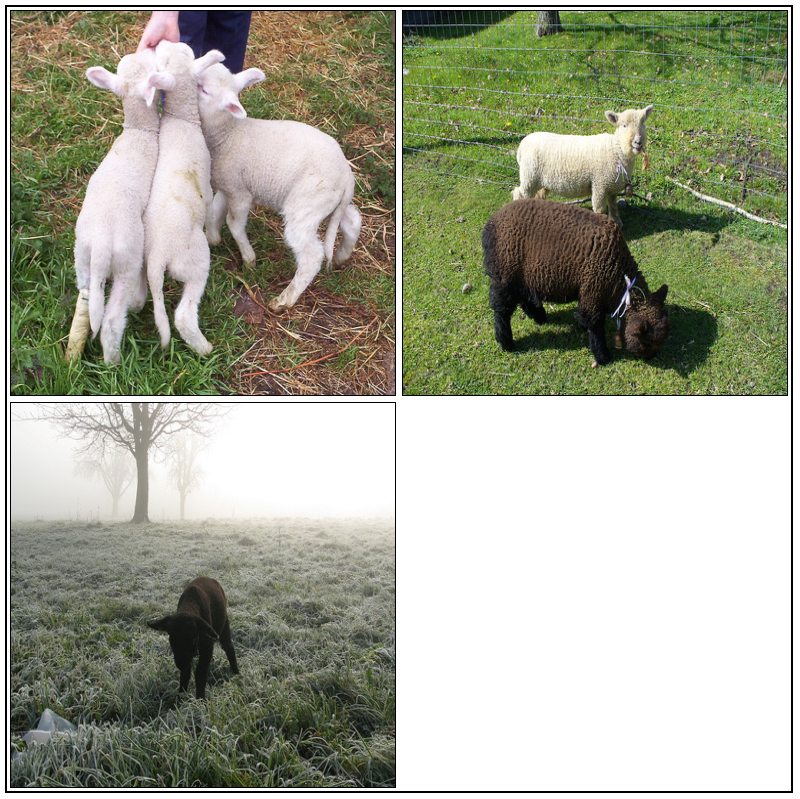

In [ ]:
from affex.data.utils import BatchKeys
from affex.utils.segmentation import unnormalize

input_dict, gt = batch
unnormalize(input_dict[BatchKeys.IMAGES]).rgb

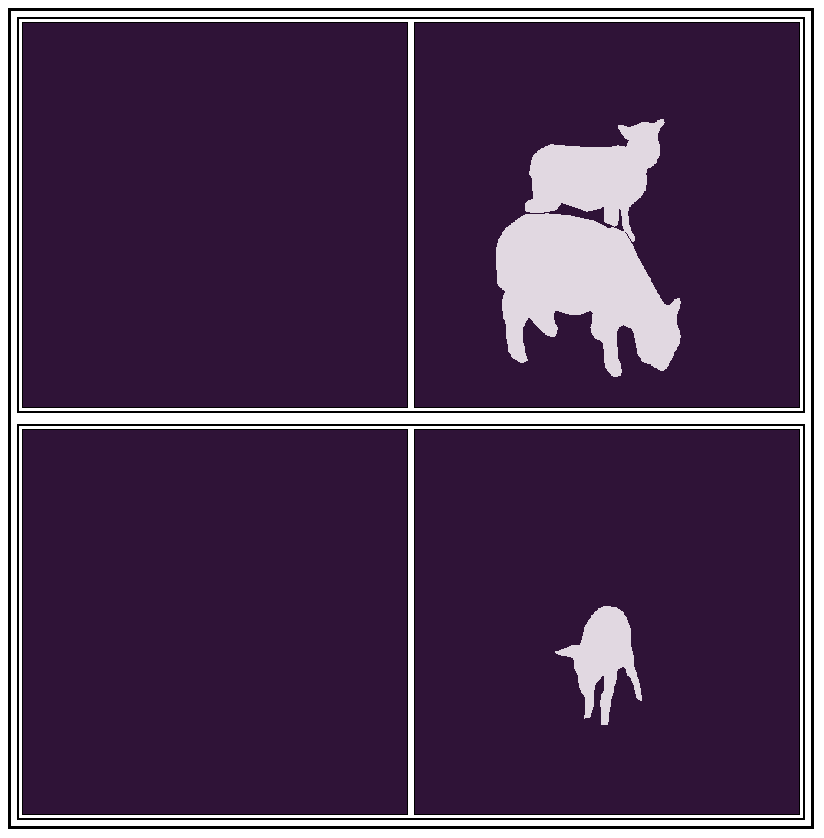

In [8]:
input_dict[BatchKeys.PROMPT_MASKS].chans

In [9]:

def gkern(klen, nsig):
    """Returns a Gaussian kernel array.
    Convolution with it results in image blurring."""
    # create nxn zeros
    inp = np.zeros((klen, klen))
    # set element at the middle to one, a dirac delta
    inp[klen//2, klen//2] = 1
    # gaussian-smooth the dirac, resulting in a gaussian filter mask
    k = gaussian_filter(inp, nsig)
    kern = np.zeros((3, 3, klen, klen))
    kern[0, 0] = k
    kern[1, 1] = k
    kern[2, 2] = k
    return torch.from_numpy(kern.astype('float32'))

def auc(arr):
    """Returns normalized Area Under Curve of the array."""
    return (arr.sum() - arr[0] / 2 - arr[-1] / 2) / (arr.shape[0] - 1)

class CausalMetric():

    def __init__(self, model, mode, step, substrate_fn):
        r"""Create deletion/insertion metric instance.

        Args:
            model (nn.Module): Black-box model being explained.
            mode (str): 'del' or 'ins'.
            step (int): number of pixels modified per one iteration.
            substrate_fn (func): a mapping from old pixels to new pixels.
        """
        assert mode in ['del', 'ins']
        self.model = model
        self.mode = mode
        self.step = step
        self.substrate_fn = substrate_fn

    def single_run(self, img_tensor, explanation, verbose=0, save_to=None):
        r"""Run metric on one image-saliency pair.

        Args:
            img_tensor (Tensor): normalized image tensor.
            explanation (np.ndarray): saliency map.
            verbose (int): in [0, 1, 2].
                0 - return list of scores.
                1 - also plot final step.
                2 - also plot every step and print 2 top classes.
            save_to (str): directory to save every step plots to.

        Return:
            scores (nd.array): Array containing scores at every step.
        """
        device = img_tensor.device
        with torch.no_grad():
            pred = self.model(img_tensor)
        top, c = torch.max(pred, 1)
        c = c.cpu().numpy()[0]
        n_steps = (HW + self.step - 1) // self.step

        if self.mode == 'del':
            title = 'Deletion game'
            ylabel = 'Pixels deleted'
            start = img_tensor.clone()
            finish = self.substrate_fn(img_tensor)
        elif self.mode == 'ins':
            title = 'Insertion game'
            ylabel = 'Pixels inserted'
            start = self.substrate_fn(img_tensor)
            finish = img_tensor.clone()

        scores = np.empty(n_steps + 1)
        # Coordinates of pixels in order of decreasing saliency
        salient_order = np.flip(np.argsort(explanation.reshape(-1, HW), axis=1), axis=-1)
        for i in range(n_steps+1):
            pred = self.model(start.to(device))
            pr, cl = torch.topk(pred, 2)
            if verbose == 2:
                print('{}: {:.3f}'.format((cl[0][0]), float(pr[0][0])))
                print('{}: {:.3f}'.format((cl[0][1]), float(pr[0][1])))
            scores[i] = pred[0, c]
            # Render image if verbose, if it's the last step or if save is required.
            if verbose == 2 or (verbose == 1 and i == n_steps) or save_to:
                plt.figure(figsize=(10, 5))
                plt.subplot(121)
                plt.title('{} {:.1f}%, P={:.4f}'.format(ylabel, 100 * i / n_steps, scores[i]))
                plt.axis('off')
                tensor_imshow(start[0])

                plt.subplot(122)
                plt.plot(np.arange(i+1) / n_steps, scores[:i+1])
                plt.xlim(-0.1, 1.1)
                plt.ylim(0, 1.05)
                plt.fill_between(np.arange(i+1) / n_steps, 0, scores[:i+1], alpha=0.4)
                plt.title(title)
                plt.xlabel(ylabel)
                plt.ylabel(c)
                if save_to:
                    plt.savefig(save_to + '/{:03d}.png'.format(i))
                    plt.close()
                else:
                    plt.show()
            if i < n_steps:
                coords = salient_order[:, self.step * i:self.step * (i + 1)]
                start.cpu().numpy().reshape(1, 3, HW)[0, :, coords] = finish.cpu().numpy().reshape(1, 3, HW)[0, :, coords]
        return scores

    def evaluate(self, img_batch, exp_batch, batch_size):
        r"""Efficiently evaluate big batch of images.

        Args:
            img_batch (Tensor): batch of images.
            exp_batch (np.ndarray): batch of explanations.
            batch_size (int): number of images for one small batch.

        Returns:
            scores (nd.array): Array containing scores at every step for every image.
        """
        device = img_batch.device
        n_samples = img_batch.shape[0]
        predictions = torch.FloatTensor(n_samples, C)
        assert n_samples % batch_size == 0
        for i in tqdm(range(n_samples // batch_size), desc='Predicting labels'):
            with torch.no_grad():
                preds = self.model(img_batch[i*batch_size:(i+1)*batch_size].to(device)).cpu()
            predictions[i*batch_size:(i+1)*batch_size] = preds
        top = np.argmax(predictions, -1)
        n_steps = (HW + self.step - 1) // self.step
        scores = np.empty((n_steps + 1, n_samples))
        salient_order = np.flip(np.argsort(exp_batch.reshape(-1, HW), axis=1), axis=-1)
        r = np.arange(n_samples).reshape(n_samples, 1)

        substrate = torch.zeros_like(img_batch)
        for j in tqdm(range(n_samples // batch_size), desc='Substrate'):
            substrate[j*batch_size:(j+1)*batch_size] = self.substrate_fn(img_batch[j*batch_size:(j+1)*batch_size])

        if self.mode == 'del':
            caption = 'Deleting  '
            start = img_batch.clone()
            finish = substrate
        elif self.mode == 'ins':
            caption = 'Inserting '
            start = substrate
            finish = img_batch.clone()

        # While not all pixels are changed
        for i in tqdm(range(n_steps+1), desc=caption + 'pixels'):
            # Iterate over batches
            for j in range(n_samples // batch_size):
                # Compute new scores
                with torch.no_grad():
                    preds = self.model(start[j*batch_size:(j+1)*batch_size].to(device))
                preds = preds.cpu().numpy()[range(batch_size), top[j*batch_size:(j+1)*batch_size]]
                scores[i, j*batch_size:(j+1)*batch_size] = preds
            # Change specified number of most salient pixels to substrate pixels
            coords = salient_order[:, self.step * i:self.step * (i + 1)]
            start.cpu().numpy().reshape(n_samples, 3, HW)[r, :, coords] = finish.cpu().numpy().reshape(n_samples, 3, HW)[r, :, coords]
        print('AUC: {}'.format(auc(scores.mean(1))))
        return scores

In [ ]:
from einops import rearrange
from affex.data.utils import BatchKeys
from affex.utils.utils import ResultDict, to_device

import torch.nn.functional as F


class FSSCausalMetric():

    def __init__(self, model, mode, step, substrate_fn):
        r"""Create deletion/insertion metric instance.

        Args:
            model (nn.Module): Black-box model being explained.
            mode (str): 'del' or 'ins'.
            step (int): number of pixels modified per one iteration.
            substrate_fn (func): a mapping from old pixels to new pixels.
        """
        assert mode in ['del', 'ins']
        self.model = model
        self.mode = mode
        self.step = step
        self.substrate_fn = substrate_fn
        self.reduce = lambda x : torch.mean(x, dim=-1)
        
        self.xauc = None
        self.scores = None
        self.n_steps = None
        
    def get_start_finish(self, input_dict):
        images = input_dict[BatchKeys.IMAGES]
        masks = input_dict[BatchKeys.PROMPT_MASKS]
        B, M, C, H, W = masks.shape
        
        query_image = images[:, 0:1]
        support_images = images[:, 1:]
        
        substrate_images = self.substrate_fn(support_images)
        substrate_masks = self.substrate_fn(masks)
        
        if self.mode == 'del':
            caption = 'Deleting  '
            start_si = support_images.clone()
            start_masks = masks.clone()
            finish_si = substrate_images
            finish_masks = substrate_masks
            start = {
                **input_dict,
                BatchKeys.IMAGES: torch.cat([query_image, start_si], dim=1),
                BatchKeys.PROMPT_MASKS: start_masks
            }
            finish = {
                **input_dict,
                BatchKeys.IMAGES: torch.cat([query_image, finish_si], dim=1),
                BatchKeys.PROMPT_MASKS: finish_masks
            }
            
        elif self.mode == 'ins':
            caption = 'Inserting '
            start_si = substrate_images
            start_masks = substrate_masks
            finish_si = support_images.clone()
            finish_masks = masks.clone()
            start = {
                **input_dict,
                BatchKeys.IMAGES: torch.cat([query_image, start_si], dim=1),
                BatchKeys.PROMPT_MASKS: start_masks
            }
            finish = {
                **input_dict,
                BatchKeys.IMAGES: torch.cat([query_image, finish_si], dim=1),
                BatchKeys.PROMPT_MASKS: finish_masks
            }
            
        return start, finish, caption
    
    def finish_to_start(self, start, finish, coords):
        start_masks = rearrange(start[BatchKeys.PROMPT_MASKS], 'B M C H W -> C (B M H W)')
        finish_masks = rearrange(finish[BatchKeys.PROMPT_MASKS], 'B M C H W -> C (B M H W)')
        start_images = start[BatchKeys.IMAGES]
        query_image = start_images[:, 0:1]
        start_support_images = rearrange(start_images[:, 1:], 'B M C H W -> C (B M H W)')
        finish_support_images = rearrange(finish[BatchKeys.IMAGES][:, 1:], 'B M C H W -> C (B M H W)')
        B, M, C, H, W = start[BatchKeys.PROMPT_MASKS].shape
        MHW = H * W * M
        
        # coords: [B, K] — indices into last dim (flattened)]
        coords = rearrange(coords, 'B K -> (B K)')
        # gather values
        start_support_images[:, coords] = finish_support_images[:, coords]
        start_support_images = rearrange(start_support_images, 'C (B M H W) -> B M C H W', M=M, H=H, W=W)
        
        start_masks[:, coords] = finish_masks[:, coords]
        start_masks = rearrange(start_masks, 'C (B M H W) -> B M C H W', M=M, H=H, W=W)
        start_images = torch.cat([query_image, start_support_images], dim=1)
        start[BatchKeys.IMAGES] = start_images
        start[BatchKeys.PROMPT_MASKS] = start_masks
        return start
    
    def evaluate(self, input_dict, explanation, explanation_mask):
        r"""Non-interactive evaluation: returns final xAUC and all scores."""
        for _ in self._evaluate_core(input_dict, explanation, explanation_mask, interactive=False):
            pass
        return self.xauc, self.scores


    def evaluate_interactive(self, input_dict, explanation, explanation_mask):
        r"""Interactive evaluation: yields intermediate states."""
        yield from self._evaluate_core(input_dict, explanation, explanation_mask, interactive=True)

    def _evaluate_core(self, input_dict, explanation, explanation_mask, interactive):
        r"""Efficiently evaluate big batch of images.

        Args:
            input_dict (dict): dictionary containing image tensor, image masks
            exp_batch (np.ndarray): saliency map over the support iamges
            explanation_mask (torch.tensor): mask over the query image

        Returns:
            scores (nd.array): Array containing scores at every step for every image.
        """
        images = input_dict[BatchKeys.IMAGES]
        masks = input_dict[BatchKeys.PROMPT_MASKS]
        B, M, C, H, W = masks.shape
        MHW = H * W * M
        
        device = images.device
        with torch.no_grad():
            result = self.model(to_device(input_dict, device), postprocess=False)
            preds = F.softmax(result[ResultDict.LOGITS], dim=1)
            preds = self.reduce(preds[:, :, explanation_mask]) # Reduce over the selected pixels -> [B, C, S] (S number of selected pixels) -> [B, C]
        top = torch.argmax(preds, -1)
        self.n_steps = (MHW + self.step - 1) // self.step
        scores = torch.empty((self.n_steps + 1, B))
        salient_order = torch.sort(explanation.reshape(-1, MHW), dim=1, descending=True)[1]

        start, finish, caption = self.get_start_finish(input_dict)

        # While not all pixels are changed
        for i in tqdm(range(self.n_steps+1), desc=caption + 'pixels'):
            # clear_output()
            # display(unnormalize(start[BatchKeys.IMAGES][0, 1:]).rgb)
            # display(unnormalize(finish[BatchKeys.IMAGES][0, 1:]).rgb)
            # Compute new scores
            with torch.no_grad():
                result = self.model(to_device(start, device), postprocess=False)
                preds = F.softmax(result[ResultDict.LOGITS], dim=1)
            preds = self.reduce(preds[:, :, explanation_mask]) # Reduce over the selected pixels -> [B, C, S] (S number of selected pixels) -> [B, C]
            top_preds = preds[:, top] # Take the top classes for each batch
            scores[i] = top_preds
            # Change specified number of most salient pixels to substrate pixels
            coords = salient_order[:, self.step * i:self.step * (i + 1)]
            start = self.finish_to_start(start, finish, coords)
            if interactive:
                yield start, i, scores[:i+1]
        self.xauc = auc(scores.mean(1))
        self.scores = scores 

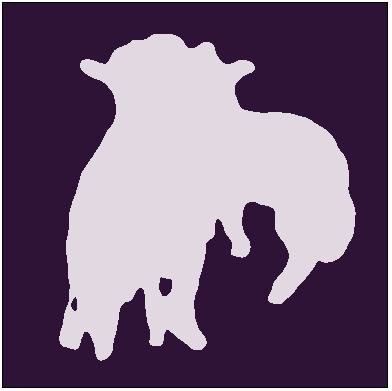

In [ ]:
from affex.explainer import calculate_explanations
from affex.utils.utils import ResultDict

import torch.nn.functional as F

input_dict = to_device(input_dict, device)
target_shape = input_dict[BatchKeys.IMAGES][:, 0].shape[2:]

with torch.no_grad():
    result = model(input_dict, postprocess=False)

logits = F.interpolate(
            result[ResultDict.LOGITS],
            size=target_shape,
            mode="bilinear",
            align_corners=False,
            antialias=False,
        ).argmax(dim=1)
explanation_mask = F.one_hot(logits, num_classes=n_ways+1).permute(0, 3, 1, 2)[0].bool()
logits.chans

In [12]:
masks = input_dict[BatchKeys.PROMPT_MASKS]
flag_examples = input_dict[BatchKeys.FLAG_EXAMPLES]
    
explanation = calculate_explanations(model, result, masks, flag_examples, explanation_mask, n_ways, target_shape)

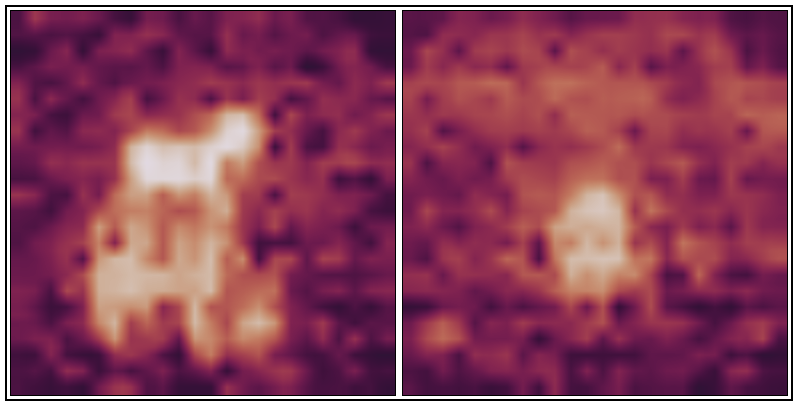

In [13]:
weighted_explanation = explanation[0][1]
weighted_explanation = rearrange(weighted_explanation, 'B H (M W) -> B M H W', W=target_shape[1], M=n_shots)
weighted_explanation.chans

In [14]:
fssmetric = FSSCausalMetric(model, 'ins', 1000, torch.zeros_like)

Inserting pixels:   1%|▏         | 4/296 [00:00<00:15, 19.19it/s]

Inserting pixels: 100%|██████████| 296/296 [00:15<00:00, 19.38it/s]

xAUC: tensor 0.956


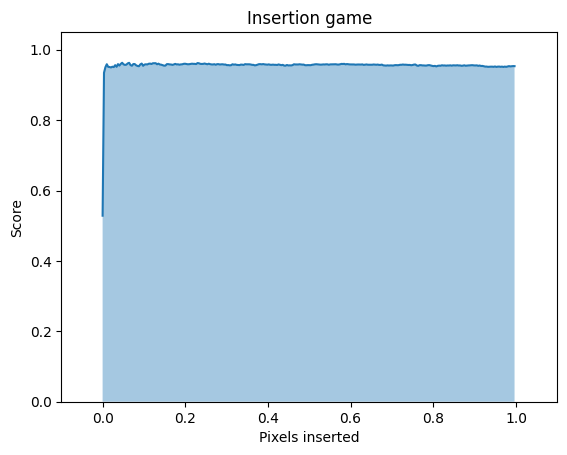

In [15]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

xauc, scores = fssmetric.evaluate(input_dict, weighted_explanation, explanation_mask[1])
batch_element = 0
print('xAUC:', xauc)
# Plot scores
plt.plot(np.arange(scores.shape[0]) / scores.shape[0], scores[:, batch_element])
plt.fill_between(np.arange(scores.shape[0]) / scores.shape[0], 0, scores[:, batch_element], alpha=0.4)
plt.xlim(-0.1, 1.1)
plt.ylim(0, 1.05)
plt.xlabel('Pixels inserted')
plt.ylabel('Score')
plt.title('Insertion game')
plt.show()

In [16]:
# for start, i, scores in fssmetric.evaluate_interactive(batch, explanation, explanation_mask):
#     print('Step {}: {}'.format(i, scores))
#     # display(start[BatchKeys.IMAGES][:, 1:].rgb)
#     ylabel = 'Pixels inserted'
#     plt.figure(figsize=(10, 5))
#     plt.subplot(121)
#     plt.title('{} {:.1f}%'.format(ylabel, 100 * i / fssmetric.n_steps))
#     plt.axis('off')

#     plt.subplot(122)
#     plt.plot(np.arange(i+1) / fssmetric.n_steps, scores[:i+1])
#     plt.xlim(-0.1, 1.1)
#     plt.ylim(0, 1.05)
#     plt.fill_between(np.arange(i+1) / fssmetric.n_steps, 0, scores[0, :i+1], alpha=0.4)
#     plt.xlabel(ylabel)
#     plt.ylabel('Score')
#     plt.show()
    
#     time.sleep(2)
#     clear_output(wait=True)